# FER2013 Analysis Notebook

## Emotion Face Classifier

This notebook performs initial analysis with this data set only.

Data prep and analysis include:
- Sampling/balancing data
- Train-test split
- Modeling and saving models

In [2]:
import os
import numpy as np
import pandas as pd

In [3]:
def check_directory_name(target_name) -> bool:
    """
    Check if the current directory name matches the target_name.
    If not, move up a directory and repeat the check.
    
    Args:
        target_name (str): The directory name to match.
        
    Returns:
        bool: True if the current directory name matches the target_name, False otherwise.
    """
    # Get the current directory path
    current_dir = os.getcwd()
    
    # Extract the directory name from the path
    current_dir_name = os.path.basename(current_dir)
    
    # Check if the current directory name matches the target_name
    if current_dir_name == target_name:
        print(f'Directory set to {current_dir}, matches target dir sting {target_name}.')
        return True
    else:
        # Move up a directory
        os.chdir('..')
        # Check if we have reached the root directory
        if os.getcwd() == current_dir:
            return False
        # Recursively call the function to check the parent directory
        return check_directory_name(target_name)

In [4]:
main_dir = 'EmotionFaceClassifier'
check_directory_name(main_dir)

Directory set to /Users/dsl/Documents/GitHub/EmotionFaceClassifier, matches target dir sting EmotionFaceClassifier.


True

In [5]:
from src.main import (
    convert_pixels_to_array,
    str_to_array,
    load_config
)

## Data Import and Prep

In [7]:
df_path = 'data/fer2013/fer2013.csv'
df = pd.read_csv(df_path)

In [8]:
# Load common dicts from json config file
common_dicts = load_config('./configs/basics.json')
print(common_dicts.keys())

dict_keys(['usage_dict', 'emo_dict', 'emo_color_dict', 'output_col_order'])


In [9]:
# Load in key dicts from json for data mapping
emo_dict = common_dicts['emo_dict']
emo_color_dict = common_dicts['emo_color_dict']

In [10]:
### Optional, view dicts from json
# print(emo_dict)
# print('\n')
# print(emo_color_dict)

In [11]:
# Modify df for clarity
df = df.rename(columns={'emotion': 'emotion_id'})
df['emotion'] = df['emotion_id'].astype(str).map(emo_dict)
df['color'] = df['emotion'].map(emo_color_dict)

In [12]:
# Pixel data is read in as str, must be converted to np.array 48x48
df['image'] = df['pixels'].apply(convert_pixels_to_array)

In [13]:
# Pixel data is read in as str, converted to a flat array (2304,)
df['flat_array'] = df['pixels'].apply(str_to_array)

## Flat Array Models

- Decision Tree Classifier
- Random Foreset Classifier

In [15]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

In [16]:
def print_metrics(y_test, y_pred):
    """function to display model metrics in a human readable fashion
    y_test: Array of true y values
    y_pred: Arrah of predicted y values
    """
    scores = [accuracy_score, recall_score, precision_score, f1_score]
    s_labels = ['Accuracy', 'Recall', 'Precision', 'F1']
    for score, s_label in zip(scores, s_labels):
        if s_label == 'Accuracy':
            print(f"{s_label}: {score(y_test, y_pred): .2f}")
        else:
            print(f"{s_label}: {score(y_test, y_pred, average='weighted'):.2f}")

In [17]:
# X = df['flat_array']
X = np.stack(df['flat_array'].values)

y = df['emotion']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=42,
    stratify=y
)

In [19]:
X_train.shape

(26915, 2304)

In [20]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
dt_predictions = dt.predict(X_test)

In [22]:
print_metrics(y_test, dt_predictions)

Accuracy:  0.31
Recall: 0.31
Precision: 0.31
F1: 0.31


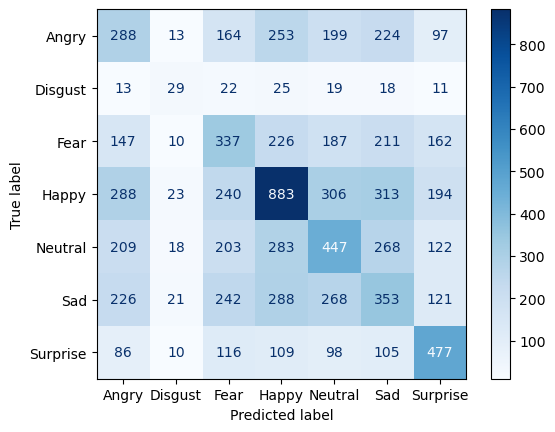

In [23]:
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_true=y_test,
    y_pred=dt_predictions, 
    cmap='Blues'
)

In [24]:
rf = RandomForestClassifier(n_estimators=25, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=25, random_state=42)

In [25]:
rf_predictions = rf.predict(X_test)

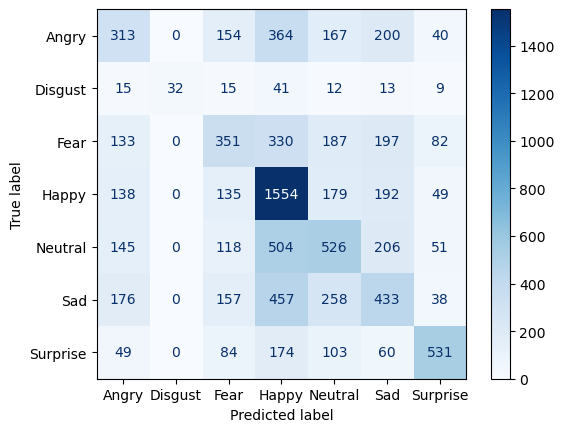

In [26]:
cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=rf_predictions, 
    cmap='Blues'
)

In [28]:
print_metrics(y_test, rf_predictions)

Accuracy:  0.42
Recall: 0.42
Precision: 0.42
F1: 0.40


### TODOs
Save metrics and cm
Use pre-selected train-test split